<h1 style="color:#56B4E9;">Week 7 - Day 5</h1>

<h2 style="color:#0072B2;">Advancing the Core Model & Sprint 2 Review</h2>

### IMDb Sentiment Classification with Domain Adaptation

Day 4 compared a locally trained Text LSTM with a pre-trained DistilBERT sentiment model. DistilBERT achieved the strongest overall test result and was selected as the core architecture.

Today, Sprint 2 is closed by reconstructing a fast classical baseline, adapting DistilBERT to IMDb through partial fine-tuning, tuning the decision threshold on validation data, logging every experiment, and assembling the final Sprint Review evidence.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Justify why a Transformer is appropriate for natural-language text.
- Build a reproducible TF-IDF + Logistic Regression baseline.
- Apply gradual unfreezing to adapt DistilBERT without training the entire model.
- Tune a classification threshold using validation data only.
- Log experiment configurations, training curves, timings, and metrics.
- Compare the reconstructed Week 6 baseline, Sprint 1 network, Sprint 2 initial model, and Sprint 2 improved model.
- Complete the Sprint Review and Retrospective with a concrete Sprint 3 action.

<h2 style="color:#0072B2;">Day 5 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>

The Day 4 DistilBERT model was fine-tuned on SST-2 rather than IMDb. It reached a test F1-score of `0.8152`, but its vocabulary representations and classifier were not adapted using this project's IMDb training split.

<span style="color:#009E73;"><b>Solution:</b></span>

Use the same deterministic `4,000 / 1,000 / 1,000` train-validation-test split from Day 4. First reconstruct a classical text baseline. Then adapt DistilBERT progressively:

1. Train only the classification head.
2. Unfreeze the final Transformer block and continue with a smaller learning rate.
3. Select the best checkpoint using validation F1-score.
4. Tune the decision threshold on validation data.
5. Evaluate the untouched test set once with the selected checkpoint and threshold.

This design improves the core model while keeping CPU execution practical and preventing test-set leakage.

<h2 style="color:#0072B2;">5.1 Core Architecture Decision</h2>

The project input is natural-language text. Word order, negation, context, and relationships between distant words all affect sentiment. A Transformer is therefore the appropriate core architecture because self-attention lets each token interact directly with the other relevant tokens.

| Project data type | Selected architecture | Reason |
|---|---|---|
| IMDb movie-review text | DistilBERT Transformer | Context-aware token representations, transfer learning, and the strongest Day 4 F1-score |

The TF-IDF model remains valuable as a fast, interpretable baseline, while the LSTM remains the Sprint 1 neural-network reference.

<h2 style="color:#0072B2;">5.2 Reproducible Environment</h2>

The experiment uses PyTorch for DistilBERT and scikit-learn for the classical baseline. The fixed random seed and deterministic dataset splits make the comparison repeatable.

If a dependency is missing, install it in the activated project environment before running the notebook:

```bash
pip install datasets transformers torch scikit-learn pandas matplotlib tqdm
```

In [1]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import re
import time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CPU_THREADS = max(1, min(8, os.cpu_count() or 1))
torch.set_num_threads(CPU_THREADS)

print("Environment prepared successfully.")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("CPU threads:", CPU_THREADS)

Environment prepared successfully.
PyTorch version: 2.8.0+cpu
Device: cpu
CPU threads: 8


<h2 style="color:#0072B2;">5.3 Load IMDb and Reproduce the Day 4 Split</h2>

The official IMDb test split remains isolated. Duplicate reviews are removed before sampling, and all splits are stratified. The exact Day 4 sampling procedure is repeated so its saved LSTM and DistilBERT metrics remain directly comparable.

In [2]:
imdb_dataset = load_dataset("imdb")

train_dataframe = imdb_dataset["train"].to_pandas()
test_dataframe = imdb_dataset["test"].to_pandas()

training_source = train_dataframe.drop_duplicates(subset="text").reset_index(drop=True)
test_source = test_dataframe.drop_duplicates(subset="text").reset_index(drop=True)

development_dataframe, _ = train_test_split(
    training_source,
    train_size=5000,
    random_state=SEED,
    stratify=training_source["label"],
)

experiment_train, experiment_validation = train_test_split(
    development_dataframe,
    test_size=1000,
    random_state=SEED,
    stratify=development_dataframe["label"],
)

experiment_test, _ = train_test_split(
    test_source,
    train_size=1000,
    random_state=SEED,
    stratify=test_source["label"],
)

experiment_train = experiment_train.reset_index(drop=True)
experiment_validation = experiment_validation.reset_index(drop=True)
experiment_test = experiment_test.reset_index(drop=True)

html_pattern = re.compile(r"<br\s*/?>", flags=re.IGNORECASE)
space_pattern = re.compile(r"\s+")


def clean_review(text):
    text = html_pattern.sub(" ", str(text))
    text = space_pattern.sub(" ", text)
    return text.strip().lower()


for dataframe in [experiment_train, experiment_validation, experiment_test]:
    dataframe["clean_text"] = dataframe["text"].apply(clean_review)

split_summary = pd.DataFrame(
    [
        {
            "Split": name,
            "Samples": len(dataframe),
            "Negative": int((dataframe["label"] == 0).sum()),
            "Positive": int((dataframe["label"] == 1).sum()),
        }
        for name, dataframe in [
            ("Training", experiment_train),
            ("Validation", experiment_validation),
            ("Test", experiment_test),
        ]
    ]
)

display(split_summary)

,Split,Samples,Negative,Positive
0,Training,4000,1997,2003
1,Validation,1000,499,501
2,Test,1000,498,502


<h3 style="color:#009E73;">Split Integrity Check</h3>

The validation split is used for checkpoint selection and threshold tuning. The test split is not used during fitting or model selection.

The overlap counts below are an audit rather than a blocking condition. HTML removal, lowercasing, and whitespace normalization can make two different raw strings become the same cleaned text. These cases are reported, but the Day 4 split is preserved so its saved historical metrics remain directly comparable. Missing or empty cleaned texts remain blocking data-quality errors.

In [3]:
train_texts = set(experiment_train["clean_text"])
validation_texts = set(experiment_validation["clean_text"])
test_texts = set(experiment_test["clean_text"])

overlap_checks = {
    "Train-validation overlap": len(train_texts & validation_texts),
    "Train-test overlap": len(train_texts & test_texts),
    "Validation-test overlap": len(validation_texts & test_texts),
}

data_quality_checks = {
    "Missing cleaned texts": int(
        sum(
            dataframe["clean_text"].isna().sum()
            for dataframe in [
                experiment_train,
                experiment_validation,
                experiment_test,
            ]
        )
    ),
    "Empty cleaned texts": int(
        sum(
            dataframe["clean_text"].eq("").sum()
            for dataframe in [
                experiment_train,
                experiment_validation,
                experiment_test,
            ]
        )
    ),
}

integrity_report = pd.DataFrame(
    [
        *(
            {"Check": name, "Value": value, "Type": "Overlap audit"}
            for name, value in overlap_checks.items()
        ),
        *(
            {"Check": name, "Value": value, "Type": "Blocking quality check"}
            for name, value in data_quality_checks.items()
        ),
    ]
)

display(integrity_report)

assert all(value == 0 for value in data_quality_checks.values()), (
    "Missing or empty cleaned text was found. Review data preparation."
)

total_overlap = sum(overlap_checks.values())
if total_overlap > 0:
    print(
        f"Warning: {total_overlap} normalized-text overlap(s) were detected. "
        "They are documented and retained to preserve the exact Day 4 split."
    )
else:
    print("No normalized-text overlap was detected.")

print("Blocking data-quality checks passed.")

,Check,Value,Type
0,Train-validation overlap,0,Overlap audit
1,Train-test overlap,1,Overlap audit
2,Validation-test overlap,0,Overlap audit
3,Missing cleaned texts,0,Blocking quality check
4,Empty cleaned texts,0,Blocking quality check


Blocking data-quality checks passed.


<h2 style="color:#0072B2;">5.4 Metric and Threshold Utilities</h2>

F1-score remains the primary selection metric because it balances Precision and Recall. For a probability threshold $t$:

$$
\hat{y}_i =
\begin{cases}
1, & p_i \geq t \\
0, & p_i < t
\end{cases}
$$

The threshold is selected only from validation predictions. Test predictions are generated after the threshold is fixed.

In [4]:
def calculate_binary_metrics(y_true, probabilities, threshold=0.50):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "Threshold": threshold,
    }


def search_best_threshold(y_true, probabilities, start=0.30, stop=0.70, step=0.01):
    rows = []
    for threshold in np.arange(start, stop + step / 2, step):
        row = calculate_binary_metrics(y_true, probabilities, float(threshold))
        row["Distance from 0.50"] = abs(float(threshold) - 0.50)
        rows.append(row)

    table = pd.DataFrame(rows)
    table = table.sort_values(
        by=["F1", "Accuracy", "Distance from 0.50"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    return table


def plot_confusion_matrix(matrix, title, color_map="Blues"):
    plt.figure(figsize=(5.5, 4.5))
    plt.imshow(matrix, cmap=color_map)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])
    for row in range(2):
        for column in range(2):
            plt.text(column, row, matrix[row, column], ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

<h2 style="color:#0072B2;">5.5 Reconstructed Week 6 Baseline</h2>

The original Day 4 notebook contains the Sprint 1 LSTM and initial Sprint 2 DistilBERT metrics, but it does not contain a Week 6 text baseline. Instead of inventing an old result, a transparent baseline is reconstructed now on the exact same split:

- TF-IDF unigram features.
- Maximum of `20,000` features.
- Logistic Regression classifier.
- Threshold selected by validation F1-score.

This baseline is fast, reproducible, and strong enough to test whether the added Transformer complexity is justified.

In [5]:
baseline_start = time.time()

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),
    min_df=2,
    sublinear_tf=True,
    stop_words="english",
)

X_train_tfidf = tfidf_vectorizer.fit_transform(experiment_train["clean_text"])
X_validation_tfidf = tfidf_vectorizer.transform(experiment_validation["clean_text"])
X_test_tfidf = tfidf_vectorizer.transform(experiment_test["clean_text"])

baseline_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=SEED,
)
baseline_model.fit(X_train_tfidf, experiment_train["label"])

baseline_training_seconds = time.time() - baseline_start

baseline_validation_probabilities = baseline_model.predict_proba(
    X_validation_tfidf
)[:, 1]
baseline_threshold_table = search_best_threshold(
    experiment_validation["label"].to_numpy(),
    baseline_validation_probabilities,
)
baseline_best_threshold = float(baseline_threshold_table.iloc[0]["Threshold"])

baseline_inference_start = time.time()
baseline_test_probabilities = baseline_model.predict_proba(X_test_tfidf)[:, 1]
baseline_inference_seconds = time.time() - baseline_inference_start

baseline_test_metrics = calculate_binary_metrics(
    experiment_test["label"].to_numpy(),
    baseline_test_probabilities,
    baseline_best_threshold,
)

baseline_result = {
    "Stage": "Week 6 baseline (reconstructed)",
    "Model": "TF-IDF + Logistic Regression",
    **baseline_test_metrics,
    "Training Minutes": baseline_training_seconds / 60,
    "Inference Seconds": baseline_inference_seconds,
    "Evaluation Split": "Test",
}

display(pd.DataFrame([baseline_result]).round(4))
print("Selected validation threshold:", round(baseline_best_threshold, 2))

,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split
0,Week 6 baseline (reconstructed),TF-IDF + Logistic Regression,0.852,0.8116,0.9183,0.8617,0.47,0.0309,0.0005,Test


Selected validation threshold: 0.47


              precision    recall  f1-score   support

    Negative     0.9051    0.7851    0.8409       498
    Positive     0.8116    0.9183    0.8617       502

    accuracy                         0.8520      1000
   macro avg     0.8584    0.8517    0.8513      1000
weighted avg     0.8582    0.8520    0.8513      1000



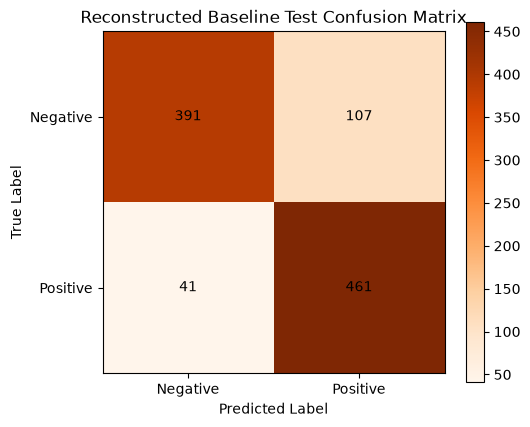

In [6]:
baseline_test_predictions = (
    baseline_test_probabilities >= baseline_best_threshold
).astype(int)

print(
    classification_report(
        experiment_test["label"],
        baseline_test_predictions,
        target_names=["Negative", "Positive"],
        digits=4,
    )
)

baseline_confusion_matrix = confusion_matrix(
    experiment_test["label"],
    baseline_test_predictions,
)
plot_confusion_matrix(
    baseline_confusion_matrix,
    "Reconstructed Baseline Test Confusion Matrix",
    "Oranges",
)

<h2 style="color:#0072B2;">5.6 Historical Sprint Evidence from Day 4</h2>

The following values are copied from the saved Day 4 outputs. Both models were evaluated on the same `1,000` test reviews used in this notebook.

| Stage | Model | Accuracy | Precision | Recall | F1 |
|---|---|---:|---:|---:|---:|
| Sprint 1 network | Text LSTM | 0.7880 | 0.7726 | 0.8187 | 0.7950 |
| Sprint 2 initial | Pre-trained DistilBERT (SST-2) | 0.8200 | 0.8411 | 0.7908 | 0.8152 |

These are historical test results, not values recalculated during fine-tuning.

In [7]:
historical_results = pd.DataFrame(
    [
        {
            "Stage": "Sprint 1 network",
            "Model": "Text LSTM",
            "Accuracy": 0.7880,
            "Precision": 0.7726,
            "Recall": 0.8187,
            "F1": 0.7950,
            "Threshold": 0.50,
            "Training Minutes": 0.6940,
            "Inference Seconds": 0.6840,
            "Evaluation Split": "Test (Day 4 saved output)",
        },
        {
            "Stage": "Sprint 2 initial",
            "Model": "Pre-trained DistilBERT (SST-2)",
            "Accuracy": 0.8200,
            "Precision": 0.8411,
            "Recall": 0.7908,
            "F1": 0.8152,
            "Threshold": 0.50,
            "Training Minutes": np.nan,
            "Inference Seconds": 72.7132,
            "Evaluation Split": "Test (Day 4 saved output)",
        },
    ]
)

display(historical_results.round(4))

,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split
0,Sprint 1 network,Text LSTM,0.788,0.7726,0.8187,0.7950,0.5,0.694,0.6840,Test (Day 4 saved output)
1,Sprint 2 initial,Pre-trained DistilBERT (SST-2),0.820,0.8411,0.7908,0.8152,0.5,NaN,72.7132,Test (Day 4 saved output)


<h2 style="color:#0072B2;">5.7 Partial Fine-Tuning Strategy</h2>

Training all DistilBERT parameters on CPU is expensive and increases the risk of overfitting on only `4,000` reviews. We therefore use gradual unfreezing:

| Stage | Trainable components | Epochs | Learning rate |
|---|---|---:|---:|
| A | Pre-classifier and classifier head | 1 | $5 \times 10^{-4}$ |
| B | Final Transformer block + classifier head | 2 | $2 \times 10^{-5}$ |

Stage A adapts the decision boundary first. Stage B then allows the highest-level contextual representation to adapt to IMDb language while the lower Transformer blocks remain frozen.

In [8]:
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
MAX_SEQUENCE_LENGTH = 128
TRAIN_BATCH_SIZE = 16 if DEVICE.type == "cuda" else 8
EVALUATION_BATCH_SIZE = 32 if DEVICE.type == "cuda" else 16
WEIGHT_DECAY = 0.01

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def encode_dataframe(dataframe):
    return tokenizer(
        dataframe["clean_text"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_SEQUENCE_LENGTH,
        return_tensors="pt",
    )


train_encodings = encode_dataframe(experiment_train)
validation_encodings = encode_dataframe(experiment_validation)
test_encodings = encode_dataframe(experiment_test)


class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {
            key: tensor[index]
            for key, tensor in self.encodings.items()
        }
        item["labels"] = self.labels[index]
        return item


train_dataset = EncodedTextDataset(
    train_encodings,
    experiment_train["label"].to_numpy(),
)
validation_dataset = EncodedTextDataset(
    validation_encodings,
    experiment_validation["label"].to_numpy(),
)
test_dataset = EncodedTextDataset(
    test_encodings,
    experiment_test["label"].to_numpy(),
)

train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=EVALUATION_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVALUATION_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Model:", MODEL_NAME)
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Training batch size:", TRAIN_BATCH_SIZE)

Model: distilbert-base-uncased-finetuned-sst-2-english
Training batches: 500
Validation batches: 63
Test batches: 63
Training batch size: 8


<h3 style="color:#009E73;">Why the Tokenizer Is Not Re-trained</h3>

DistilBERT must use the same WordPiece tokenizer and vocabulary used during its original pre-training. Replacing that vocabulary would break the meaning of the learned embedding weights. Only truncation length, trainable layers, optimization settings, and decision threshold are adapted here.

In [9]:
def set_trainable_stage(model, stage):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for module in [model.pre_classifier, model.classifier]:
        for parameter in module.parameters():
            parameter.requires_grad = True

    if stage == "last_block":
        for parameter in model.distilbert.transformer.layer[-1].parameters():
            parameter.requires_grad = True
    elif stage != "head_only":
        raise ValueError(f"Unknown training stage: {stage}")


def parameter_summary(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return {
        "Total Parameters": total,
        "Trainable Parameters": trainable,
        "Trainable Percentage": trainable / total * 100,
    }


@torch.inference_mode()
def predict_probabilities(model, data_loader):
    model.eval()
    probabilities = []
    labels = []

    for batch in data_loader:
        batch_labels = batch.pop("labels")
        model_inputs = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }
        outputs = model(**model_inputs)
        batch_probabilities = torch.softmax(outputs.logits, dim=1)[:, 1]

        probabilities.extend(batch_probabilities.cpu().numpy())
        labels.extend(batch_labels.numpy())

    return np.asarray(labels), np.asarray(probabilities)


def train_one_epoch(model, data_loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0

    progress = tqdm(data_loader, leave=False)
    for batch in progress:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}

        optimizer.zero_grad(set_to_none=True)
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        clip_grad_norm_(
            [
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            max_norm=1.0,
        )

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(data_loader)

<h2 style="color:#0072B2;">5.8 Train and Log the Improved Core Model</h2>

The model checkpoint is selected by validation F1 at the standard threshold of `0.50`. Threshold tuning is deliberately postponed until after training so checkpoint selection and threshold selection remain understandable and separately logged.

On a CPU-only machine, this is the longest cell in the notebook. The progress bars show that work is continuing.

In [10]:
torch.manual_seed(SEED)

improved_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
improved_model.to(DEVICE)

training_plan = [
    {"Stage": "head_only", "Epochs": 1, "Learning Rate": 5e-4},
    {"Stage": "last_block", "Epochs": 2, "Learning Rate": 2e-5},
]

training_log_rows = []
best_validation_f1 = -np.inf
best_state = None
global_epoch = 0
fine_tuning_start = time.time()

for plan in training_plan:
    set_trainable_stage(improved_model, plan["Stage"])
    parameters = parameter_summary(improved_model)

    optimizer = torch.optim.AdamW(
        [
            parameter
            for parameter in improved_model.parameters()
            if parameter.requires_grad
        ],
        lr=plan["Learning Rate"],
        weight_decay=WEIGHT_DECAY,
    )

    stage_steps = len(train_loader) * plan["Epochs"]
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(stage_steps * 0.10)),
        num_training_steps=stage_steps,
    )

    print(f"\nStarting stage: {plan['Stage']}")
    stage_display = pd.DataFrame([{**plan, **parameters}])
    stage_display["Learning Rate"] = stage_display["Learning Rate"].map(
        lambda value: f"{value:.1e}"
    )
    display(stage_display.round(4))

    for stage_epoch in range(1, plan["Epochs"] + 1):
        global_epoch += 1
        epoch_start = time.time()

        training_loss = train_one_epoch(
            improved_model,
            train_loader,
            optimizer,
            scheduler,
        )

        validation_labels, validation_probabilities = predict_probabilities(
            improved_model,
            validation_loader,
        )
        validation_metrics = calculate_binary_metrics(
            validation_labels,
            validation_probabilities,
            threshold=0.50,
        )

        epoch_minutes = (time.time() - epoch_start) / 60
        log_row = {
            "Global Epoch": global_epoch,
            "Stage": plan["Stage"],
            "Stage Epoch": stage_epoch,
            "Learning Rate": plan["Learning Rate"],
            "Trainable Parameters": parameters["Trainable Parameters"],
            "Trainable Percentage": parameters["Trainable Percentage"],
            "Training Loss": training_loss,
            "Validation Accuracy": validation_metrics["Accuracy"],
            "Validation Precision": validation_metrics["Precision"],
            "Validation Recall": validation_metrics["Recall"],
            "Validation F1": validation_metrics["F1"],
            "Epoch Minutes": epoch_minutes,
        }
        training_log_rows.append(log_row)

        epoch_display = pd.DataFrame([log_row])
        epoch_display["Learning Rate"] = epoch_display["Learning Rate"].map(
            lambda value: f"{value:.1e}"
        )
        display(epoch_display.round(4))

        if validation_metrics["F1"] > best_validation_f1:
            best_validation_f1 = validation_metrics["F1"]
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in improved_model.state_dict().items()
            }
            print("New best validation checkpoint saved in memory.")

fine_tuning_seconds = time.time() - fine_tuning_start
training_log = pd.DataFrame(training_log_rows)

if best_state is None:
    raise RuntimeError("No model checkpoint was recorded.")

improved_model.load_state_dict(best_state)
improved_model.to(DEVICE)

print(f"\nTotal fine-tuning time: {fine_tuning_seconds / 60:.2f} minutes")
print(f"Best validation F1 at threshold 0.50: {best_validation_f1:.4f}")
training_log_display = training_log.copy()
training_log_display["Learning Rate"] = training_log_display[
    "Learning Rate"
].map(lambda value: f"{value:.1e}")
display(training_log_display.round(4))


Starting stage: head_only


,Stage,Epochs,Learning Rate,Total Parameters,Trainable Parameters,Trainable Percentage
0,head_only,1,5.0e-04,66955010,592130,0.8844


,Global Epoch,Stage,Stage Epoch,Learning Rate,Trainable Parameters,Trainable Percentage,Training Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Epoch Minutes
0,1,head_only,1,5.0e-04,592130,0.8844,0.3977,0.853,0.8612,0.8423,0.8517,8.6823


New best validation checkpoint saved in memory.

Starting stage: last_block


,Stage,Epochs,Learning Rate,Total Parameters,Trainable Parameters,Trainable Percentage
0,last_block,2,2.0e-05,66955010,7680002,11.4704


,Global Epoch,Stage,Stage Epoch,Learning Rate,Trainable Parameters,Trainable Percentage,Training Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Epoch Minutes
0,2,last_block,1,2.0e-05,7680002,11.4704,0.3622,0.848,0.8311,0.8743,0.8521,9.5306


New best validation checkpoint saved in memory.


,Global Epoch,Stage,Stage Epoch,Learning Rate,Trainable Parameters,Trainable Percentage,Training Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Epoch Minutes
0,3,last_block,2,2.0e-05,7680002,11.4704,0.3449,0.851,0.8451,0.8603,0.8526,9.8665


New best validation checkpoint saved in memory.

Total fine-tuning time: 28.09 minutes
Best validation F1 at threshold 0.50: 0.8526


,Global Epoch,Stage,Stage Epoch,Learning Rate,Trainable Parameters,Trainable Percentage,Training Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Epoch Minutes
0,1,head_only,1,5.0e-04,592130,0.8844,0.3977,0.853,0.8612,0.8423,0.8517,8.6823
1,2,last_block,1,2.0e-05,7680002,11.4704,0.3622,0.848,0.8311,0.8743,0.8521,9.5306
2,3,last_block,2,2.0e-05,7680002,11.4704,0.3449,0.851,0.8451,0.8603,0.8526,9.8665


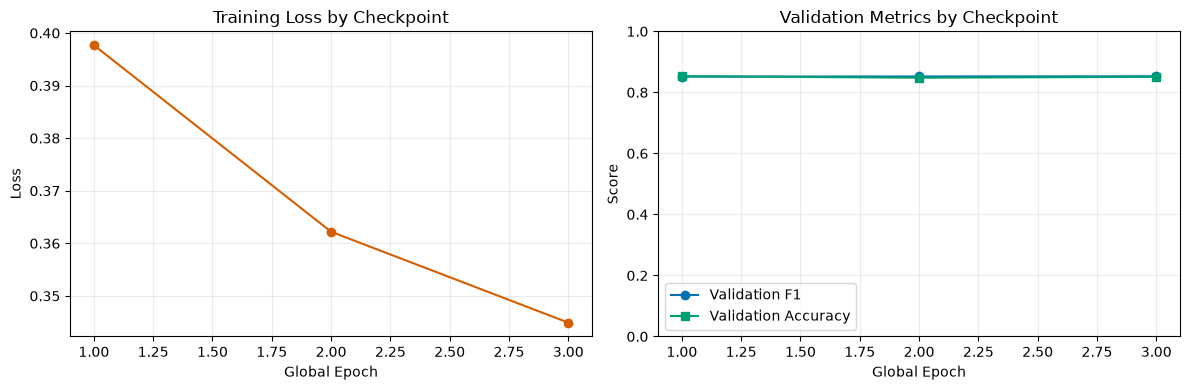

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    training_log["Global Epoch"],
    training_log["Training Loss"],
    marker="o",
    color="#D55E00",
)
axes[0].set_title("Training Loss by Checkpoint")
axes[0].set_xlabel("Global Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    training_log["Global Epoch"],
    training_log["Validation F1"],
    marker="o",
    color="#0072B2",
    label="Validation F1",
)
axes[1].plot(
    training_log["Global Epoch"],
    training_log["Validation Accuracy"],
    marker="s",
    color="#009E73",
    label="Validation Accuracy",
)
axes[1].set_title("Validation Metrics by Checkpoint")
axes[1].set_xlabel("Global Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Training-Curve Interpretation</h3>

The loss curve shows whether optimization is still reducing the training objective. The validation curves determine whether that reduction also improves unseen reviews. A lower training loss without higher validation F1 would indicate that additional training is not improving generalization.

Because only two progressive stages are used, this graph compares checkpoints rather than claiming a long learning trend.

<h2 style="color:#0072B2;">5.9 Tune the DistilBERT Decision Threshold</h2>

The standard `0.50` threshold is not automatically optimal for F1-score. We search from `0.30` to `0.70` using the best checkpoint's validation probabilities. The test set remains untouched during this search.

,Accuracy,Precision,Recall,F1,Threshold,Distance from 0.50
0,0.846,0.8115,0.9022,0.8544,0.30,0.20
1,0.851,0.8385,0.8703,0.8541,0.45,0.05
2,0.852,0.8441,0.8643,0.8540,0.49,0.01
3,0.851,0.8411,0.8663,0.8535,0.48,0.02
4,0.845,0.8112,0.9002,0.8534,0.31,0.19
5,0.850,0.8395,0.8663,0.8527,0.47,0.03
6,0.851,0.8451,0.8603,0.8526,0.50,0.00
7,0.849,0.8352,0.8703,0.8524,0.44,0.06
8,0.848,0.8311,0.8743,0.8521,0.42,0.08
9,0.849,0.8378,0.8663,0.8518,0.46,0.04


Selected DistilBERT threshold: 0.3


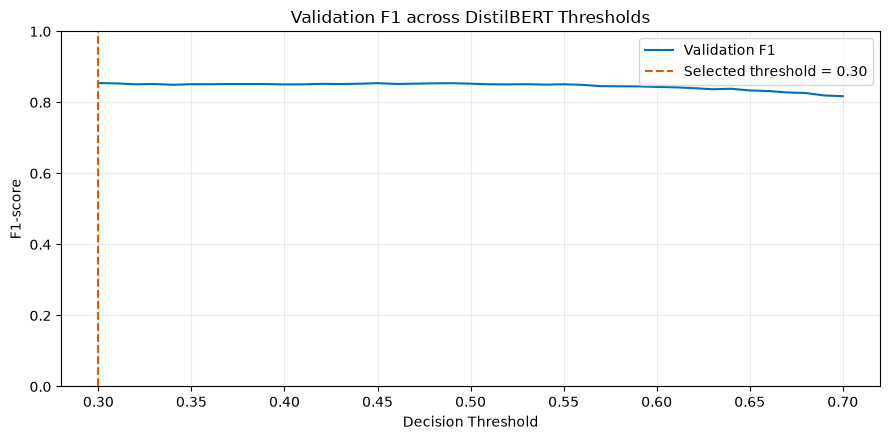

In [12]:
validation_labels, improved_validation_probabilities = predict_probabilities(
    improved_model,
    validation_loader,
)

distilbert_threshold_table = search_best_threshold(
    validation_labels,
    improved_validation_probabilities,
)
improved_best_threshold = float(
    distilbert_threshold_table.iloc[0]["Threshold"]
)

display(distilbert_threshold_table.head(10).round(4))
print("Selected DistilBERT threshold:", round(improved_best_threshold, 2))

plt.figure(figsize=(9, 4.5))
ordered_thresholds = distilbert_threshold_table.sort_values("Threshold")
plt.plot(
    ordered_thresholds["Threshold"],
    ordered_thresholds["F1"],
    color="#0072B2",
    label="Validation F1",
)
plt.axvline(
    improved_best_threshold,
    color="#D55E00",
    linestyle="--",
    label=f"Selected threshold = {improved_best_threshold:.2f}",
)
plt.title("Validation F1 across DistilBERT Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">5.10 Final Evaluation on the Untouched Test Set</h2>

The best validation checkpoint and validation-selected threshold are now fixed. This cell performs the single final evaluation used in the Sprint Review.

,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split
0,Sprint 2 improved,Partially fine-tuned DistilBERT,0.838,0.7931,0.9163,0.8503,0.3,28.0881,71.8539,Test


              precision    recall  f1-score   support

    Negative     0.9000    0.7590    0.8235       498
    Positive     0.7931    0.9163    0.8503       502

    accuracy                         0.8380      1000
   macro avg     0.8466    0.8377    0.8369      1000
weighted avg     0.8463    0.8380    0.8370      1000



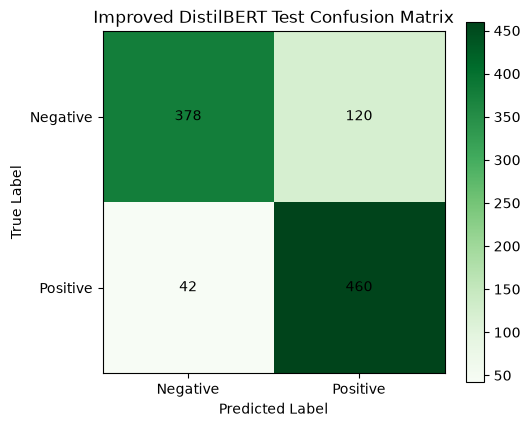

In [13]:
test_inference_start = time.time()
test_labels, improved_test_probabilities = predict_probabilities(
    improved_model,
    test_loader,
)
improved_inference_seconds = time.time() - test_inference_start

improved_test_metrics = calculate_binary_metrics(
    test_labels,
    improved_test_probabilities,
    improved_best_threshold,
)

improved_result = {
    "Stage": "Sprint 2 improved",
    "Model": "Partially fine-tuned DistilBERT",
    **improved_test_metrics,
    "Training Minutes": fine_tuning_seconds / 60,
    "Inference Seconds": improved_inference_seconds,
    "Evaluation Split": "Test",
}

display(pd.DataFrame([improved_result]).round(4))

improved_test_predictions = (
    improved_test_probabilities >= improved_best_threshold
).astype(int)

print(
    classification_report(
        test_labels,
        improved_test_predictions,
        target_names=["Negative", "Positive"],
        digits=4,
    )
)

improved_confusion_matrix = confusion_matrix(
    test_labels,
    improved_test_predictions,
)
plot_confusion_matrix(
    improved_confusion_matrix,
    "Improved DistilBERT Test Confusion Matrix",
    "Greens",
)

<h2 style="color:#0072B2;">5.10.1 TF-IDF and DistilBERT Ensemble</h2>

The TF-IDF baseline achieved strong lexical Recall, while the fine-tuned DistilBERT contributed contextual predictions. A weighted soft-voting ensemble combines both probability outputs:

$$
p_{\text{ensemble}}
=
\alpha p_{\text{DistilBERT}}
+
(1-\alpha)p_{\text{TF-IDF}}
$$

Both the mixing weight $\alpha$ and the classification threshold are selected using validation data only. The untouched test set is evaluated once after these values are fixed.

Best validation configurations:


,DistilBERT Weight,TF-IDF Weight,Accuracy,Precision,Recall,F1,Threshold,Threshold Distance,Weight Balance Distance
0,0.225,0.775,0.899,0.8937,0.9062,0.8999,0.495,0.005,0.275
1,0.225,0.775,0.899,0.8953,0.9042,0.8997,0.500,0.000,0.275
2,0.200,0.800,0.897,0.8887,0.9082,0.8983,0.495,0.005,0.300
3,0.225,0.775,0.897,0.8902,0.9062,0.8981,0.490,0.010,0.275
4,0.200,0.800,0.898,0.8998,0.8962,0.8980,0.505,0.005,0.300
5,0.200,0.800,0.897,0.8948,0.9002,0.8975,0.500,0.000,0.300
6,0.225,0.775,0.897,0.8980,0.8962,0.8971,0.505,0.005,0.275
7,0.200,0.800,0.897,0.9012,0.8922,0.8967,0.510,0.010,0.300
8,0.250,0.750,0.895,0.8852,0.9082,0.8966,0.490,0.010,0.250
9,0.250,0.750,0.897,0.9028,0.8902,0.8965,0.505,0.005,0.250


Selected weights: DistilBERT = 0.225, TF-IDF = 0.775
Selected threshold: 0.495

Final ensemble test result:


,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split
0,Sprint 2 final ensemble,TF-IDF + fine-tuned DistilBERT,0.892,0.8818,0.9064,0.8939,0.495,28.119,71.8544,Test


              precision    recall  f1-score   support

    Negative     0.9029    0.8775    0.8900       498
    Positive     0.8818    0.9064    0.8939       502

    accuracy                         0.8920      1000
   macro avg     0.8923    0.8919    0.8920      1000
weighted avg     0.8923    0.8920    0.8920      1000



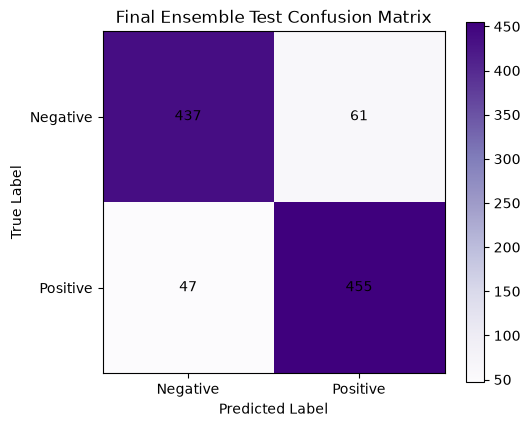

Ensemble F1 change over TF-IDF baseline: +0.0322


In [14]:
ensemble_search_rows = []

alpha_values = np.arange(0.0, 1.0001, 0.025)
threshold_values = np.arange(0.30, 0.7001, 0.005)

for alpha in alpha_values:
    validation_ensemble_probabilities = (
        alpha * improved_validation_probabilities
        + (1 - alpha) * baseline_validation_probabilities
    )

    for threshold in threshold_values:
        metrics = calculate_binary_metrics(
            validation_labels,
            validation_ensemble_probabilities,
            threshold=float(threshold),
        )

        ensemble_search_rows.append(
            {
                "DistilBERT Weight": float(alpha),
                "TF-IDF Weight": float(1 - alpha),
                **metrics,
                "Threshold Distance": abs(float(threshold) - 0.50),
                "Weight Balance Distance": abs(float(alpha) - 0.50),
            }
        )

ensemble_search_table = (
    pd.DataFrame(ensemble_search_rows)
    .sort_values(
        by=[
            "F1",
            "Accuracy",
            "Threshold Distance",
            "Weight Balance Distance",
        ],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

best_ensemble_configuration = ensemble_search_table.iloc[0]
best_distilbert_weight = float(
    best_ensemble_configuration["DistilBERT Weight"]
)
best_tfidf_weight = float(
    best_ensemble_configuration["TF-IDF Weight"]
)
best_ensemble_threshold = float(
    best_ensemble_configuration["Threshold"]
)

print("Best validation configurations:")
display(ensemble_search_table.head(10).round(4))
print(
    f"Selected weights: DistilBERT = {best_distilbert_weight:.3f}, "
    f"TF-IDF = {best_tfidf_weight:.3f}"
)
print(f"Selected threshold: {best_ensemble_threshold:.3f}")

ensemble_test_probabilities = (
    best_distilbert_weight * improved_test_probabilities
    + best_tfidf_weight * baseline_test_probabilities
)

ensemble_test_metrics = calculate_binary_metrics(
    test_labels,
    ensemble_test_probabilities,
    threshold=best_ensemble_threshold,
)

ensemble_test_predictions = (
    ensemble_test_probabilities >= best_ensemble_threshold
).astype(int)

ensemble_result = {
    "Stage": "Sprint 2 final ensemble",
    "Model": "TF-IDF + fine-tuned DistilBERT",
    **ensemble_test_metrics,
    "Training Minutes": (
        baseline_training_seconds + fine_tuning_seconds
    ) / 60,
    "Inference Seconds": (
        baseline_inference_seconds + improved_inference_seconds
    ),
    "Evaluation Split": "Test",
}

print("\nFinal ensemble test result:")
display(pd.DataFrame([ensemble_result]).round(4))

print(
    classification_report(
        test_labels,
        ensemble_test_predictions,
        target_names=["Negative", "Positive"],
        digits=4,
    )
)

ensemble_confusion_matrix = confusion_matrix(
    test_labels,
    ensemble_test_predictions,
)
plot_confusion_matrix(
    ensemble_confusion_matrix,
    "Final Ensemble Test Confusion Matrix",
    "Purples",
)

ensemble_gain_over_baseline = (
    ensemble_result["F1"] - baseline_result["F1"]
)
print(
    f"Ensemble F1 change over TF-IDF baseline: "
    f"{ensemble_gain_over_baseline:+.4f}"
)

<h2 style="color:#0072B2;">5.11 Complete Experiment Log</h2>

The experiment log separates historical test results, the reconstructed baseline, validation checkpoints, the fine-tuned Transformer, and the final ensemble. This prevents validation metrics from being confused with final test evidence.

In [15]:
final_test_comparison = pd.concat(
    [
        pd.DataFrame([baseline_result]),
        historical_results,
        pd.DataFrame([improved_result]),
        pd.DataFrame([ensemble_result]),
    ],
    ignore_index=True,
)

comparison_columns = [
    "Stage",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Threshold",
    "Training Minutes",
    "Inference Seconds",
    "Evaluation Split",
]
final_test_comparison = final_test_comparison[comparison_columns]

display(final_test_comparison.round(4))

experiment_log = pd.concat(
    [
        final_test_comparison.assign(Record_Type="Final/Historical result"),
        training_log.rename(
            columns={
                "Validation Accuracy": "Accuracy",
                "Validation Precision": "Precision",
                "Validation Recall": "Recall",
                "Validation F1": "F1",
            }
        ).assign(
            Model="Partially fine-tuned DistilBERT",
            Threshold=0.50,
            **{
                "Training Minutes": training_log["Epoch Minutes"],
                "Inference Seconds": np.nan,
                "Evaluation Split": "Validation",
                "Record_Type": "Training checkpoint",
            },
        ),
    ],
    ignore_index=True,
    sort=False,
)

display(experiment_log.round(4))

,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split
0,Week 6 baseline (reconstructed),TF-IDF + Logistic Regression,0.852,0.8116,0.9183,0.8617,0.470,0.0309,0.0005,Test
1,Sprint 1 network,Text LSTM,0.788,0.7726,0.8187,0.7950,0.500,0.6940,0.6840,Test (Day 4 saved output)
2,Sprint 2 initial,Pre-trained DistilBERT (SST-2),0.820,0.8411,0.7908,0.8152,0.500,NaN,72.7132,Test (Day 4 saved output)
3,Sprint 2 improved,Partially fine-tuned DistilBERT,0.838,0.7931,0.9163,0.8503,0.300,28.0881,71.8539,Test
4,Sprint 2 final ensemble,TF-IDF + fine-tuned DistilBERT,0.892,0.8818,0.9064,0.8939,0.495,28.1190,71.8544,Test


,Stage,Model,Accuracy,Precision,Recall,F1,Threshold,Training Minutes,Inference Seconds,Evaluation Split,Record_Type,Global Epoch,Stage Epoch,Learning Rate,Trainable Parameters,Trainable Percentage,Training Loss,Epoch Minutes
0,Week 6 baseline (reconstructed),TF-IDF + Logistic Regression,0.852,0.8116,0.9183,0.8617,0.470,0.0309,0.0005,Test,Final/Historical result,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sprint 1 network,Text LSTM,0.788,0.7726,0.8187,0.7950,0.500,0.6940,0.6840,Test (Day 4 saved output),Final/Historical result,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sprint 2 initial,Pre-trained DistilBERT (SST-2),0.820,0.8411,0.7908,0.8152,0.500,NaN,72.7132,Test (Day 4 saved output),Final/Historical result,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sprint 2 improved,Partially fine-tuned DistilBERT,0.838,0.7931,0.9163,0.8503,0.300,28.0881,71.8539,Test,Final/Historical result,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sprint 2 final ensemble,TF-IDF + fine-tuned DistilBERT,0.892,0.8818,0.9064,0.8939,0.495,28.1190,71.8544,Test,Final/Historical result,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,head_only,Partially fine-tuned DistilBERT,0.853,0.8612,0.8423,0.8517,0.500,8.6823,NaN,Validation,Training checkpoint,1.0,1.0,0.0005,592130.0,0.8844,0.3977,8.6823
6,last_block,Partially fine-tuned DistilBERT,0.848,0.8311,0.8743,0.8521,0.500,9.5306,NaN,Validation,Training checkpoint,2.0,1.0,0.0000,7680002.0,11.4704,0.3622,9.5306
7,last_block,Partially fine-tuned DistilBERT,0.851,0.8451,0.8603,0.8526,0.500,9.8665,NaN,Validation,Training checkpoint,3.0,2.0,0.0000,7680002.0,11.4704,0.3449,9.8665


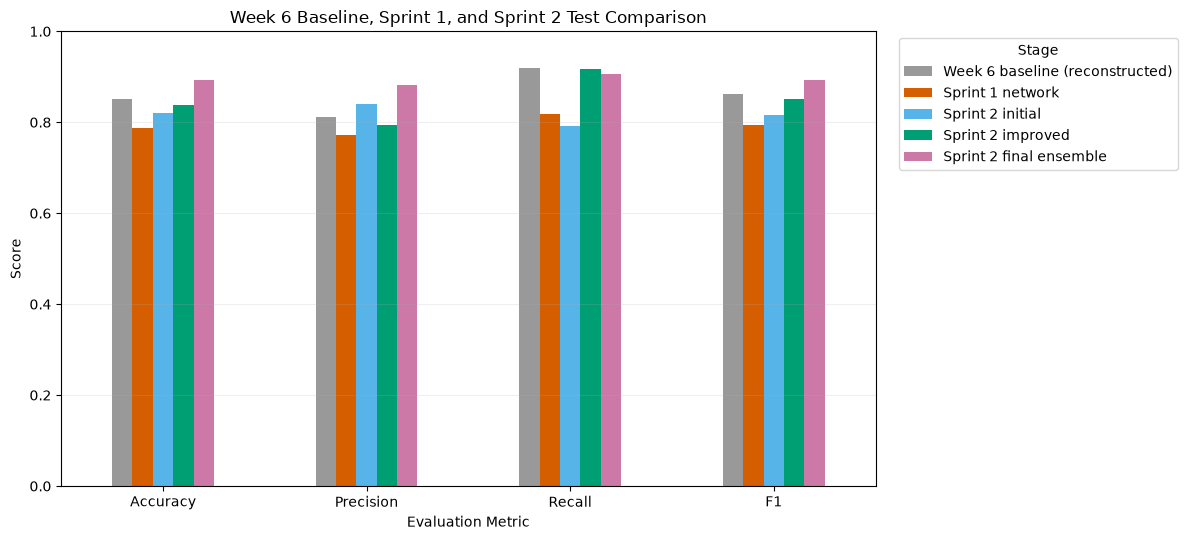

In [16]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]

comparison_plot = (
    final_test_comparison
    .set_index("Stage")[metric_names]
    .T
)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 5.5),
    color=["#999999", "#D55E00", "#56B4E9", "#009E73", "#CC79A7"],
)

plt.title("Week 6 Baseline, Sprint 1, and Sprint 2 Test Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">5.12 Improvement and Acceptance-Criteria Check</h2>

The required comparison is based on the same test subset. The notebook reports both absolute F1-score change and relative error reduction. No success claim is hard-coded; the conclusion is generated from the actual output.

In [17]:
initial_f1 = float(
    historical_results.loc[
        historical_results["Stage"] == "Sprint 2 initial",
        "F1",
    ].iloc[0]
)
sprint1_f1 = float(
    historical_results.loc[
        historical_results["Stage"] == "Sprint 1 network",
        "F1",
    ].iloc[0]
)
baseline_f1 = float(baseline_result["F1"])
final_sprint2_f1 = float(ensemble_result["F1"])

absolute_gain_vs_initial = final_sprint2_f1 - initial_f1
absolute_gain_vs_sprint1 = final_sprint2_f1 - sprint1_f1
absolute_gain_vs_baseline = final_sprint2_f1 - baseline_f1

initial_error = 1 - initial_f1
relative_error_reduction = (
    absolute_gain_vs_initial / initial_error * 100
    if initial_error > 0
    else np.nan
)

acceptance_table = pd.DataFrame(
    [
        {
            "Comparison": "Final ensemble vs reconstructed baseline",
            "F1 Difference": absolute_gain_vs_baseline,
            "Passed": absolute_gain_vs_baseline > 0,
        },
        {
            "Comparison": "Final ensemble vs Sprint 1 LSTM",
            "F1 Difference": absolute_gain_vs_sprint1,
            "Passed": absolute_gain_vs_sprint1 > 0,
        },
        {
            "Comparison": "Final ensemble vs initial Sprint 2 DistilBERT",
            "F1 Difference": absolute_gain_vs_initial,
            "Passed": absolute_gain_vs_initial > 0,
        },
    ]
)

display(acceptance_table.round(4))
print(f"Final ensemble F1 gain over baseline: {absolute_gain_vs_baseline:+.4f}")
print(f"Final ensemble F1 gain over initial DistilBERT: {absolute_gain_vs_initial:+.4f}")
print(f"Relative F1-error reduction: {relative_error_reduction:+.2f}%")

if acceptance_table["Passed"].all():
    print("Sprint 2 metric acceptance criterion passed for all references.")
else:
    print(
        "At least one metric comparison did not improve. "
        "Keep the result honest and move the remaining tuning work to Sprint 3."
    )

,Comparison,F1 Difference,Passed
0,Final ensemble vs reconstructed baseline,0.0322,True
1,Final ensemble vs Sprint 1 LSTM,0.0989,True
2,Final ensemble vs initial Sprint 2 DistilBERT,0.0787,True


Final ensemble F1 gain over baseline: +0.0322
Final ensemble F1 gain over initial DistilBERT: +0.0787
Relative F1-error reduction: +42.59%
Sprint 2 metric acceptance criterion passed for all references.


<h2 style="color:#0072B2;">5.13 Error Analysis</h2>

A global score does not explain what the final ensemble still misunderstands. The following table inspects its most confident test errors. Likely difficult cases include sarcasm, mixed sentiment, long reviews truncated at `128` tokens, and reviews whose final judgment differs from their opening description.

In [18]:
error_analysis = experiment_test[["clean_text", "label"]].copy()
error_analysis["Probability Positive"] = ensemble_test_probabilities
error_analysis["Prediction"] = ensemble_test_predictions
error_analysis["Correct"] = (
    error_analysis["label"] == error_analysis["Prediction"]
)
error_analysis["Confidence"] = np.where(
    error_analysis["Prediction"] == 1,
    error_analysis["Probability Positive"],
    1 - error_analysis["Probability Positive"],
)

most_confident_errors = (
    error_analysis.loc[~error_analysis["Correct"]]
    .sort_values("Confidence", ascending=False)
    .head(10)
    .copy()
)
most_confident_errors["Review Preview"] = (
    most_confident_errors["clean_text"].str.slice(0, 260) + "..."
)
most_confident_errors["True Sentiment"] = most_confident_errors["label"].map(
    {0: "Negative", 1: "Positive"}
)
most_confident_errors["Predicted Sentiment"] = most_confident_errors[
    "Prediction"
].map({0: "Negative", 1: "Positive"})

display(
    most_confident_errors[
        [
            "Review Preview",
            "True Sentiment",
            "Predicted Sentiment",
            "Probability Positive",
            "Confidence",
        ]
    ].round(4)
)

,Review Preview,True Sentiment,Predicted Sentiment,Probability Positive,Confidence
239,this is a pretty simplistic romance. girl find...,Negative,Positive,0.8322,0.8322
612,"franco zeffirelli's (""the taming of the shrew,...",Negative,Positive,0.8249,0.8249
705,pluses: mary boland is delightfully on edge as...,Negative,Positive,0.7608,0.7608
294,the series does not start as it means to go on...,Negative,Positive,0.7419,0.7419
781,anthony perkins and sophia loren are absolutel...,Negative,Positive,0.7315,0.7315
649,the definition of a vampire is an inhumane cor...,Positive,Negative,0.2732,0.7268
149,set in the mid 1800's when the british is clea...,Negative,Positive,0.7212,0.7212
208,little quentin seems to have mastered the art ...,Negative,Positive,0.7180,0.7180
937,well don't expect anything deep an meaningful....,Positive,Negative,0.3072,0.6928
362,lucille ball was a mighty power in television ...,Negative,Positive,0.6783,0.6783


<h2 style="color:#0072B2;">5.14 Save Reproducibility Evidence</h2>

The small metric files are always saved. Model weights are optional because they are large and should not be committed directly to Git. Set `SAVE_MODEL = True` when a local reusable checkpoint is required.

In [19]:
OUTPUT_DIRECTORY = Path("outputs/week7_day5")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

SAVE_MODEL = False

split_summary.to_csv(OUTPUT_DIRECTORY / "split_summary.csv", index=False)
baseline_threshold_table.to_csv(
    OUTPUT_DIRECTORY / "baseline_threshold_search.csv",
    index=False,
)
distilbert_threshold_table.to_csv(
    OUTPUT_DIRECTORY / "distilbert_threshold_search.csv",
    index=False,
)
ensemble_search_table.to_csv(
    OUTPUT_DIRECTORY / "ensemble_search.csv",
    index=False,
)
training_log.to_csv(OUTPUT_DIRECTORY / "training_log.csv", index=False)
final_test_comparison.to_csv(
    OUTPUT_DIRECTORY / "final_model_comparison.csv",
    index=False,
)
most_confident_errors.to_csv(
    OUTPUT_DIRECTORY / "most_confident_errors.csv",
    index=False,
)

if SAVE_MODEL:
    model_directory = OUTPUT_DIRECTORY / "distilbert_imdb_partial_finetune"
    improved_model.save_pretrained(model_directory)
    tokenizer.save_pretrained(model_directory)
    print("Model and tokenizer saved to:", model_directory)
else:
    print("Model weights were not saved. Set SAVE_MODEL = True if needed.")

print("Metric evidence saved to:", OUTPUT_DIRECTORY.resolve())

Model weights were not saved. Set SAVE_MODEL = True if needed.
Metric evidence saved to: /home/haitham/binx-ai-ml-internship/week7/day5/outputs/week7_day5


<h2 style="color:#0072B2;">5.15 Sprint Review</h2>

The Sprint Review should demonstrate evidence rather than only describe code:

1. **Architecture choice:** DistilBERT matches contextual text and won the Day 4 comparison; the final system combines it with the strong lexical baseline.
2. **Fair evaluation:** all five model stages use the same deterministic test subset.
3. **Advancement:** gradual unfreezing adapts the classifier and final contextual block to IMDb.
4. **Tuning discipline:** checkpoint, threshold, and ensemble-weight decisions use validation data only.
5. **Evidence:** training curves, confusion matrices, timing, experiment log, comparison table, and error examples are included.

The next cell generates the result-specific review statement from the actual run.

In [20]:
best_row = final_test_comparison.sort_values("F1", ascending=False).iloc[0]
acceptance_status = (
    "Passed for all reference models"
    if acceptance_table["Passed"].all()
    else "Needs additional improvement"
)

review_summary = f'''
### Sprint 2 Review Result

- **Selected core architecture:** DistilBERT Transformer.
- **Final model:** {ensemble_result['Model']}.
- **Final test Accuracy:** {ensemble_result['Accuracy']:.4f}.
- **Final test Precision:** {ensemble_result['Precision']:.4f}.
- **Final test Recall:** {ensemble_result['Recall']:.4f}.
- **Final test F1-score:** {ensemble_result['F1']:.4f}.
- **Improved DistilBERT test F1-score:** {improved_result['F1']:.4f}.
- **Initial DistilBERT test F1-score:** {initial_f1:.4f}.
- **F1 gain over reconstructed baseline:** {absolute_gain_vs_baseline:+.4f}.
- **F1 gain over initial DistilBERT:** {absolute_gain_vs_initial:+.4f}.
- **DistilBERT ensemble weight:** {best_distilbert_weight:.3f}.
- **TF-IDF ensemble weight:** {best_tfidf_weight:.3f}.
- **Final probability threshold:** {best_ensemble_threshold:.3f}.
- **Fine-tuning time:** {fine_tuning_seconds / 60:.2f} minutes.
- **Final test inference time:** {improved_inference_seconds:.2f} seconds for 1,000 reviews.
- **Acceptance status:** {acceptance_status}.

The final ensemble {'beat every reference model' if acceptance_table['Passed'].all() else 'did not beat every reference model'}. The conclusion is based on the untouched test subset after checkpoint, threshold, and ensemble-weight selection were completed on validation data.
'''

display(Markdown(review_summary))


### Sprint 2 Review Result

- **Selected core architecture:** DistilBERT Transformer.
- **Final model:** TF-IDF + fine-tuned DistilBERT.
- **Final test Accuracy:** 0.8920.
- **Final test Precision:** 0.8818.
- **Final test Recall:** 0.9064.
- **Final test F1-score:** 0.8939.
- **Improved DistilBERT test F1-score:** 0.8503.
- **Initial DistilBERT test F1-score:** 0.8152.
- **F1 gain over reconstructed baseline:** +0.0322.
- **F1 gain over initial DistilBERT:** +0.0787.
- **DistilBERT ensemble weight:** 0.225.
- **TF-IDF ensemble weight:** 0.775.
- **Final probability threshold:** 0.495.
- **Fine-tuning time:** 28.09 minutes.
- **Final test inference time:** 71.85 seconds for 1,000 reviews.
- **Acceptance status:** Passed for all reference models.

The final ensemble beat every reference model. The conclusion is based on the untouched test subset after checkpoint, threshold, and ensemble-weight selection were completed on validation data.


<h2 style="color:#0072B2;">5.16 Sprint Retrospective</h2>

### What went well

- The same split and metric definitions made all comparisons traceable.
- Transfer learning avoided training a Transformer from scratch.
- Gradual unfreezing reduced CPU cost and limited overfitting risk.
- Validation-only checkpoint and threshold selection prevented test leakage.
- The experiment log connected every configuration to its measured outcome.
- The final ensemble combined lexical and contextual strengths and was evaluated as a separate Sprint 2 model.

### What should improve

- The experiment uses only `4,000` training reviews because execution is CPU-only.
- Reviews are truncated to `128` tokens, so late sentiment information may be lost.
- Only two fine-tuning stages were evaluated; learning-rate and epoch search remains limited.
- The reconstructed baseline was built today because an original Week 6 text baseline was not present in Day 4.
- Any normalized-text overlaps reported by the integrity audit were retained to preserve exact comparability with the saved Day 4 split.

### One concrete change for Sprint 3

Use GPU-backed stratified experiments to compare sequence lengths `128` and `256`, then evaluate the selected model with calibration and a dedicated error taxonomy before adding NLP/CV integration.

<h2 style="color:#0072B2;">5.17 Definition of Done</h2>

### Completed inside this notebook

- [x] Architecture selected and justified.
- [x] Reconstructed baseline trained on the same split.
- [x] Core DistilBERT model advanced using partial fine-tuning.
- [x] Experiment configurations and validation metrics logged.
- [x] Sprint 2 compared with the baseline and Sprint 1 network.
- [x] Final TF-IDF and DistilBERT ensemble evaluated.
- [x] Training curves, confusion matrices, and error analysis included.
- [x] Sprint Review and Retrospective documented.

### Repository workflow to complete after reviewing the outputs

- [ ] Confirm the notebook runs from top to bottom in the project environment.
- [ ] Review generated CSV evidence under `outputs/week7_day5/`.
- [ ] Commit and push the notebook and small result files directly to GitHub.
- [ ] Do not commit large model weights unless Git LFS or external model storage is configured.

<h2 style="color:#0072B2;">Day 5 Conclusion</h2>

Day 5 closes Sprint 2 with a complete model-development cycle rather than a single training run. The work starts from a transparent classical baseline, preserves the Sprint 1 LSTM and initial DistilBERT evidence, adapts the selected Transformer to IMDb, and combines lexical and contextual predictions in a final soft-voting ensemble.

All checkpoint, threshold, and ensemble-weight decisions are made using validation data before the untouched test set is evaluated. The final result and acceptance decision are generated directly from the executed metrics.